In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [141]:
import sys

In [142]:
print(sys.executable)

/usr/bin/python3


In [143]:
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "numpy<2"], check=True)

Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'numpy<2'], returncode=0)

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [145]:
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "numpy>=1.17.3,<1.25.0"], check=True)

Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'numpy>=1.17.3,<1.25.0'], returncode=0)

In [146]:
CONFIDENCE = 0.99

In [147]:
ALPHA = 1 - CONFIDENCE

In [148]:
HORIZON = 1

In [149]:
PORTFOLIO_VALUE = 100000

In [150]:
N_SIMULATIONS = 10000

In [151]:
TICKERS = ['APPL', 'MSFT', 'JPM', 'XOM']

In [152]:
WEIGHTS = np.array([0.30, 0.25, 0.25, 0.20])

In [153]:
START_DATE = '2021-01-01'
END_DATE = '2023-12-31'

In [154]:
# =======================================================
# 1. COLLECTE DES DONNÉES
# =======================================================


In [155]:
def fetch_data(tickers, start, end):
    try :
        import yfinance as yf
        print(f"Téléchargement des données pour : {tickers}")
        prices = yf.download(tickers, start = start, end=end, auto_adjust=True, progress=False)['Close']
        prices = prices.dropna()
        print(f" -->{len(prices)} jours de cotation chargés.")
        return prices
    except Exception as e :
        print(f"Impossible de télécharger les données : {e}")
        print("Génération de données simulées pour la démonstration...")
        return simulate_prices(tickers,start,end)

In [156]:
def simulate_prices(tickers, start, end):
    dates = pd.date_range(start=start, end=end,freq='B') # 'B' = jours ouvrés
    np.random.seed(42)
    prices={}
    for ticker in tickers:
        #Paramètres réalistes : drift annuel ~8%, volatilité ~20%
        mu = 0.08/252
        sigma = 0.20 / np.sqrt(252)
        S0 = np.random.uniform(100,400)
        #Simulation par récurrence : S(t+1)=S(t)*exp(mu + sigma * Z)
        returns = np.random.normal(mu, sigma, len(dates))
        prices_series = S0 * np.exp(np.cumsum(returns))
        prices[ticker] = prices_series
    return pd.DataFrame(prices, index=dates)

In [157]:
# =======================================================
# 2. CALCUL DES RENDEMENTS
# =======================================================

In [158]:
def compute_returns(prices):
 """
 Calcule les rendements logarithmiques journaliers.
 Pourquoi les log-rendements ?
 r_t = ln(P_t / P_{t-1})
 Avantages :
 - Additivité temporelle : r(t,t+n) = r(t,t+1) + ... + r(t+n-1,t+n)
 - Plus symétriques que les rendements simples
 - Couramment utilisés en finance quantitative
 Retourne :
 ----------
 returns : DataFrame -> rendements de chaque action
 port_returns : Series -> rendements du portefeuille pondéré
 """
 returns = np.log(prices / prices.shift(1)).dropna()
 # Rendement du portefeuille = somme pondérée des rendements individuels
 port_returns = returns @ WEIGHTS # produit matriciel : (N,4) x (4,) = (N,)
 print(f"\nStatistiques des rendements du portefeuille :")
 print(f" Moyenne journalière : {port_returns.mean()*100:.4f}%")
 print(f" Volatilité journalière: {port_returns.std()*100:.4f}%")
 print(f" Skewness : {port_returns.skew():.4f}")
 print(f" Kurtosis : {port_returns.kurtosis():.4f}")
 print(f" (kurtosis > 0 = queues épaisses = risque de pertes extrêmes)")
 return returns, port_returns

In [159]:
# =======================================================
# 3. VaR HISTORIQUE
# =======================================================

In [160]:
def var_historical(
    port_returns,
    alpha=ALPHA,
    value=PORTFOLIO_VALUE
):
    """
    VaR historique + Expected Shortfall.
    """

    var_pct = np.percentile(port_returns, alpha * 100)

    var_euro = -var_pct * value

    tail_losses = port_returns[port_returns <= var_pct]

    es_euro = -tail_losses.mean() * value

    return var_pct, var_euro, es_euro

In [161]:
# =======================================================
# 4. VaR PARAMÉTRIQUE (GAUSSIENNE)
# =======================================================

In [162]:
def var_parametric(port_returns, alpha=ALPHA, value=PORTFOLIO_VALUE):
 """
 Méthode 2 : VaR Paramétrique (Variance-Covariance)
 Hypothèse : Les rendements suivent une loi normale N(mu, sigma²)
 Formule : VaR = -(mu + z_alpha * sigma) * V
 où z_alpha est le quantile de la loi normale standard
 (pour alpha=1% : z_alpha = -2.326)
 Avantages :
 - Simple et rapide à calculer
 - Analytiquement traçable (dérivable, optimisable)
 - Extension naturelle au portefeuille via la matrice de covariance
 Limites :
 - L'hypothèse gaussienne est souvent invalide en finance
 - Les rendements réels ont des queues plus épaisses (leptokurtose)
 - Sous-estime les pertes extrêmes (événements rares)
 Retourne :
 ----------
 var_pct : float -> VaR en pourcentage
 var_euro : float -> VaR en euros
 es_euro : float -> Expected Shortfall (formule analytique sous gaussien)
 """
 mu = port_returns.mean()
 sigma = port_returns.std()
 # Quantile de la loi normale standard à alpha%
 z_alpha = stats.norm.ppf(alpha) # ≈ -2.326 pour alpha=1%
 var_pct = mu + z_alpha * sigma
 var_euro = -var_pct * value
 # ES analytique sous gaussien :
 # ES = -(mu - sigma * phi(z_alpha) / alpha)
 # où phi est la densité de la loi normale standard
 phi_z = stats.norm.pdf(z_alpha)
 es_pct = -(mu - sigma * phi_z / alpha)
 es_euro = es_pct * value
 return var_pct, var_euro, es_euro

In [163]:
# =======================================================
# 5. VaR MONTE CARLO
# =======================================================

In [164]:
def var_monte_carlo(port_returns, alpha=ALPHA, value=PORTFOLIO_VALUE,
 n_sim=N_SIMULATIONS):
 """
 Méthode 3 : VaR Monte Carlo
 Principe : Simuler un grand nombre de scénarios de rendements
 futurs possibles, puis lire le quantile sur la distribution simulée.
 Étapes :
 1. Estimer mu et sigma sur les données historiques
 2. Simuler n_sim rendements selon N(mu, sigma²)
 3. Lire le quantile alpha sur les rendements simulés
 Avantages :
 - Très flexible (peut utiliser n'importe quelle distribution)
 - Gère la non-linéarité (options, produits structurés)
 - Permet de modéliser des corrélations complexes
 Limites :
 - Coûteux en calcul (mais gérable avec numpy)
 - Résultats dépendent de la distribution supposée
 - Erreur de simulation (diminue avec n_sim)
 Retourne :
 ----------
 var_pct : float -> VaR en pourcentage
 var_euro : float -> VaR en euros
 simul_returns: array -> les rendements simulés (pour visualisation)
 """
 mu = port_returns.mean()
 sigma = port_returns.std()
 # Génération de n_sim rendements gaussiens
 np.random.seed(42)
 simul_returns = np.random.normal(mu, sigma, n_sim)
 # Quantile empirique sur les simulations
 var_pct = np.percentile(simul_returns, alpha * 100)
 var_euro = -var_pct * value
 return var_pct, var_euro, simul_returns

In [165]:
# =======================================================
# 6. BACKTESTING
# =======================================================

In [166]:
def backtest(port_returns, var_pct_hist, var_pct_param, var_pct_mc,
 value=PORTFOLIO_VALUE, alpha=ALPHA):
 """
 Backtesting : Évaluer la qualité du modèle VaR
 Principe : On compare les VaR calculées (sur fenêtre glissante)
 aux pertes effectivement observées le lendemain.
 Un "dépassement" (exception / breach) se produit quand :
 rendement_observé < -VaR_prédite
 Sous H0 (modèle correct), le nombre d'exceptions suit :
 Bin(T, alpha) → on attend alpha*T exceptions
 Pour T=500 jours et alpha=1% : on attend ~5 exceptions.
 Test de Kupiec (POF - Proportion of Failures) :
 H0 : p_observé = alpha
 Statistique : LR = -2 * ln(L0/L1) ~ Chi²(1)
 """
 n = len(port_returns)
 losses = -port_returns * value # pertes positives
 # Nombre d'exceptions observées pour chaque méthode
 exceptions_hist = (losses > -var_pct_hist * value).sum()
 exceptions_param = (losses > -var_pct_param * value).sum()
 exceptions_mc = (losses > -var_pct_mc * value).sum()
 expected = alpha * n
 print(f"\n{'='*55}")
 print(f" BACKTESTING (sur {n} observations)")
 print(f"{'='*55}")
 print(f" Exceptions attendues ({alpha*100:.0f}%) : {expected:.1f}")
 print(f" {'Méthode':<20} {'Exceptions':>12} {'Taux':>10}")
 print(f" {'-'*44}")
 for name, exc in [("Historique", exceptions_hist),
                   ("Paramétrique", exceptions_param),
                   ("Monte Carlo", exceptions_mc)]:
     taux = exc / n * 100
     statut = ("✓ OK" if abs(exc - expected) < 2 * np.sqrt(expected*(1-alpha)) 
     else 
     "⚠ Dout") 
     print(f" {name:<20} {exc:>12} {taux:>9.2f}% {statut}")
 print(f"{'='*55}")
 return losses

In [167]:
# =======================================================
# 7. VISUALISATIONS
# =======================================================

In [168]:
def plot_results(
    port_returns,
    losses,
    var_hist,
    var_param,
    var_mc,
    simul_returns,
    save_path="var_portfolio_resultats.png"
):
    """
    Génère un tableau de bord VaR en 4 graphiques :

    1. Distribution des rendements avec les trois VaR
    2. Backtesting des pertes
    3. Distribution Monte Carlo
    4. Comparaison des méthodes VaR

    Paramètres
    ----------
    port_returns : array-like
        Série des rendements du portefeuille.

    losses : array-like
        Série des pertes du portefeuille en euros.

    var_hist : float
        VaR historique (rendement négatif).

    var_param : float
        VaR paramétrique (rendement négatif).

    var_mc : float
        VaR Monte Carlo (rendement négatif).

    simul_returns : array-like
        Rendements simulés Monte Carlo.

    save_path : str
        Chemin du fichier image à sauvegarder.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy import stats

    # ------------------------------------------------------------------
    # Validation et conversion des données
    # ------------------------------------------------------------------

    port_returns = np.asarray(port_returns, dtype=float)

    if hasattr(losses, "values"):
        loss_values = np.asarray(losses.values, dtype=float)
    else:
        loss_values = np.asarray(losses, dtype=float)

    simul_returns = np.asarray(simul_returns, dtype=float)

    if len(port_returns) == 0:
        raise ValueError("port_returns est vide.")

    if len(loss_values) == 0:
        raise ValueError("losses est vide.")

    if len(simul_returns) == 0:
        raise ValueError("simul_returns est vide.")

    # ------------------------------------------------------------------
    # Constantes graphiques
    # ------------------------------------------------------------------

    COLORS = {
        "hist": "#2E86AB",
        "param": "#E84855",
        "mc": "#3BB273"
    }

    alpha_pct = (1 - CONFIDENCE) * 100

    # ------------------------------------------------------------------
    # Figure principale
    # ------------------------------------------------------------------

    fig = plt.figure(figsize=(16, 12))

    fig.suptitle(
        (
            f"Value at Risk — Portefeuille {'+'.join(TICKERS)}\n"
            f"Valeur : {PORTFOLIO_VALUE:,.0f} € | "
            f"Horizon : {HORIZON} j | "
            f"Confiance : {CONFIDENCE * 100:.0f}%"
        ),
        fontsize=13,
        fontweight="bold",
        y=0.98
    )

    gs = gridspec.GridSpec(
        2,
        2,
        figure=fig,
        hspace=0.35,
        wspace=0.30
    )

    # ==================================================================
    # Graphique 1 : Distribution des rendements
    # ==================================================================

    ax1 = fig.add_subplot(gs[0, 0])

    ax1.hist(
        port_returns * 100,
        bins=60,
        density=True,
        color="#4A90D9",
        alpha=0.70,
        edgecolor="white",
        linewidth=0.4,
        label="Rendements observés"
    )

    mu_pct = port_returns.mean() * 100
    sigma_pct = port_returns.std() * 100

    if sigma_pct > 0:
        x = np.linspace(
            port_returns.min() * 100,
            port_returns.max() * 100,
            300
        )

        ax1.plot(
            x,
            stats.norm.pdf(x, mu_pct, sigma_pct),
            "k--",
            linewidth=1.5,
            alpha=0.8,
            label="Loi normale ajustée"
        )

    var_lines = [
        (var_hist, COLORS["hist"], f"VaR Hist. ({-var_hist * 100:.2f}%)"),
        (var_param, COLORS["param"], f"VaR Param. ({-var_param * 100:.2f}%)"),
        (var_mc, COLORS["mc"], f"VaR MC ({-var_mc * 100:.2f}%)")
    ]

    for var_value, color, label in var_lines:
        ax1.axvline(
            var_value * 100,
            color=color,
            linewidth=2,
            label=label
        )

    ax1.set_title(
        "Distribution des rendements journaliers",
        fontweight="bold"
    )
    ax1.set_xlabel("Rendement (%)")
    ax1.set_ylabel("Densité")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)

    # ==================================================================
    # Graphique 2 : Backtesting
    # ==================================================================

    ax2 = fig.add_subplot(gs[0, 1])

    x_loss = np.arange(len(loss_values))

    ax2.fill_between(
        x_loss,
        loss_values,
        alpha=0.40,
        color="#4A90D9",
        label="Pertes journalières"
    )

    var_hist_eur = -var_hist * PORTFOLIO_VALUE
    var_param_eur = -var_param * PORTFOLIO_VALUE

    ax2.axhline(
        var_hist_eur,
        color=COLORS["hist"],
        linestyle="--",
        linewidth=2,
        label=f"VaR Hist. ({var_hist_eur:,.0f} €)"
    )

    ax2.axhline(
        var_param_eur,
        color=COLORS["param"],
        linestyle=":",
        linewidth=2,
        label=f"VaR Param. ({var_param_eur:,.0f} €)"
    )

    breach_mask = loss_values > var_hist_eur
    breach_idx = np.where(breach_mask)[0]

    if len(breach_idx) > 0:
        ax2.scatter(
            breach_idx,
            loss_values[breach_mask],
            color="red",
            s=35,
            zorder=5,
            alpha=0.8,
            label=f"Exceptions ({breach_mask.sum()})"
        )

    ax2.set_title(
        "Backtesting : Pertes vs VaR",
        fontweight="bold"
    )
    ax2.set_xlabel("Jours")
    ax2.set_ylabel("Perte (€)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    # ==================================================================
    # Graphique 3 : Monte Carlo
    # ==================================================================

    ax3 = fig.add_subplot(gs[1, 0])

    simulated_losses = -simul_returns * PORTFOLIO_VALUE
    var_mc_eur = -var_mc * PORTFOLIO_VALUE

    ax3.hist(
        simulated_losses,
        bins=80,
        density=True,
        color=COLORS["mc"],
        alpha=0.70,
        edgecolor="white",
        linewidth=0.3,
        label=f"{N_SIMULATIONS:,} simulations"
    )

    ax3.axvline(
        var_mc_eur,
        color="darkgreen",
        linewidth=2.5,
        label=f"VaR MC = {var_mc_eur:,.0f} €"
    )

    xmax = max(ax3.get_xlim()[1], simulated_losses.max())

    ax3.axvspan(
        var_mc_eur,
        xmax,
        color="red",
        alpha=0.15,
        label=f"Queue de risque ({alpha_pct:.0f}%)"
    )

    ax3.set_title(
        "Distribution Monte Carlo des pertes",
        fontweight="bold"
    )
    ax3.set_xlabel("Perte simulée (€)")
    ax3.set_ylabel("Densité")
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=8)

    # ==================================================================
    # Graphique 4 : Comparaison des méthodes
    # ==================================================================

    ax4 = fig.add_subplot(gs[1, 1])

    methods = [
        "Historique",
        "Paramétrique",
        "Monte Carlo"
    ]

    var_euros = [
        var_hist_eur,
        var_param_eur,
        var_mc_eur
    ]

    bars = ax4.bar(
        methods,
        var_euros,
        color=[
            COLORS["hist"],
            COLORS["param"],
            COLORS["mc"]
        ],
        edgecolor="white",
        linewidth=1.2,
        alpha=0.85
    )

    offset = max(var_euros) * 0.02

    for bar, value in zip(bars, var_euros):
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f"{value:,.0f} €",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    ax4.set_title(
        "Comparaison des méthodes VaR",
        fontweight="bold"
    )

    ax4.set_ylabel("VaR (€)")
    ax4.grid(True, alpha=0.3, axis="y")
    ax4.set_ylim(0, max(var_euros) * 1.25)

    # ------------------------------------------------------------------
    # Sauvegarde
    # ------------------------------------------------------------------

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"\nGraphiques sauvegardés : {save_path}")

    plt.close(fig)

In [169]:
def main():
    print("=" * 55)
    print(" CALCUL DE LA VaR — Portefeuille d'actions")
    print("=" * 55)

    print(f" Portefeuille : {dict(zip(TICKERS, WEIGHTS))}")
    print(f" Valeur : {PORTFOLIO_VALUE:,.0f} €")
    print(f" Confiance : {CONFIDENCE * 100:.0f}%")
    print(f" Horizon : {HORIZON} jour(s)")

    # Étape 1 : Données
    prices = fetch_data(TICKERS, START_DATE, END_DATE)

    # Étape 2 : Rendements
    returns, port_returns = compute_returns(prices)

    # Étape 3 : Calcul des VaR
    var_h_pct, var_h_eur, es_h_eur = var_historical(port_returns)
    var_p_pct, var_p_eur, es_p_eur = var_parametric(port_returns)
    var_m_pct, var_m_eur, simul = var_monte_carlo(port_returns)

    # ------------------------------------------------------------------
    # Résultats
    # ------------------------------------------------------------------

    print("\n" + "=" * 55)
    print(f" RÉSULTATS — VaR à {CONFIDENCE * 100:.0f}% sur {HORIZON} jour")
    print("=" * 55)

    print(f" {'Méthode':<20} {'VaR (%)':>10} {'VaR (€)':>12}")
    print(" " + "-" * 44)

    methods = [
        ("Historique", var_h_pct, var_h_eur),
        ("Paramétrique", var_p_pct, var_p_eur),
        ("Monte Carlo", var_m_pct, var_m_eur),
    ]

    for name, pct, eur in methods:
        print(f" {name:<20} {pct * 100:>9.3f}% {eur:>11,.0f} €")

    print("\n Expected Shortfall (CVaR) :")
    print(f" {'Historique':<20} {es_h_eur:>11,.0f} €")
    print(f" {'Paramétrique':<20} {es_p_eur:>11,.0f} €")

    print("\n Interprétation :")
    print(
        f" Il y a {(1 - CONFIDENCE) * 100:.0f}% de chance "
        f"de perdre plus de {var_h_eur:,.0f} € sur l'horizon considéré."
    )
    print(
        f" Si cette perte survient, la perte moyenne attendue "
        f"est d'environ {es_h_eur:,.0f} € (Expected Shortfall)."
    )

    print("=" * 55)

    # Étape 4 : Backtesting
    losses = backtest(
        port_returns,
        var_h_pct,
        var_p_pct,
        var_m_pct
    )

    # Étape 5 : Visualisations
    plot_results(
        port_returns,
        losses,
        var_h_pct,
        var_p_pct,
        var_m_pct,
        simul
    )

    print("\nProjet terminé avec succès !")
    print("Fichier généré : var_portfolio_resultats.png")


if __name__ == "__main__":
    main()

 CALCUL DE LA VaR — Portefeuille d'actions
 Portefeuille : {'APPL': 0.3, 'MSFT': 0.25, 'JPM': 0.25, 'XOM': 0.2}
 Valeur : 100,000 €
 Confiance : 99%
 Horizon : 1 jour(s)
Impossible de télécharger les données : No module named 'yfinance'
Génération de données simulées pour la démonstration...

Statistiques des rendements du portefeuille :
 Moyenne journalière : 0.0643%
 Volatilité journalière: 0.6517%
 Skewness : 0.1214
 Kurtosis : -0.0705
 (kurtosis > 0 = queues épaisses = risque de pertes extrêmes)

 RÉSULTATS — VaR à 99% sur 1 jour
 Méthode                 VaR (%)      VaR (€)
 --------------------------------------------
 Historique              -1.342%       1,342 €
 Paramétrique            -1.452%       1,452 €
 Monte Carlo             -1.448%       1,448 €

 Expected Shortfall (CVaR) :
 Historique                 1,484 €
 Paramétrique               1,673 €

 Interprétation :
 Il y a 1% de chance de perdre plus de 1,342 € sur l'horizon considéré.
 Si cette perte survient, la perte

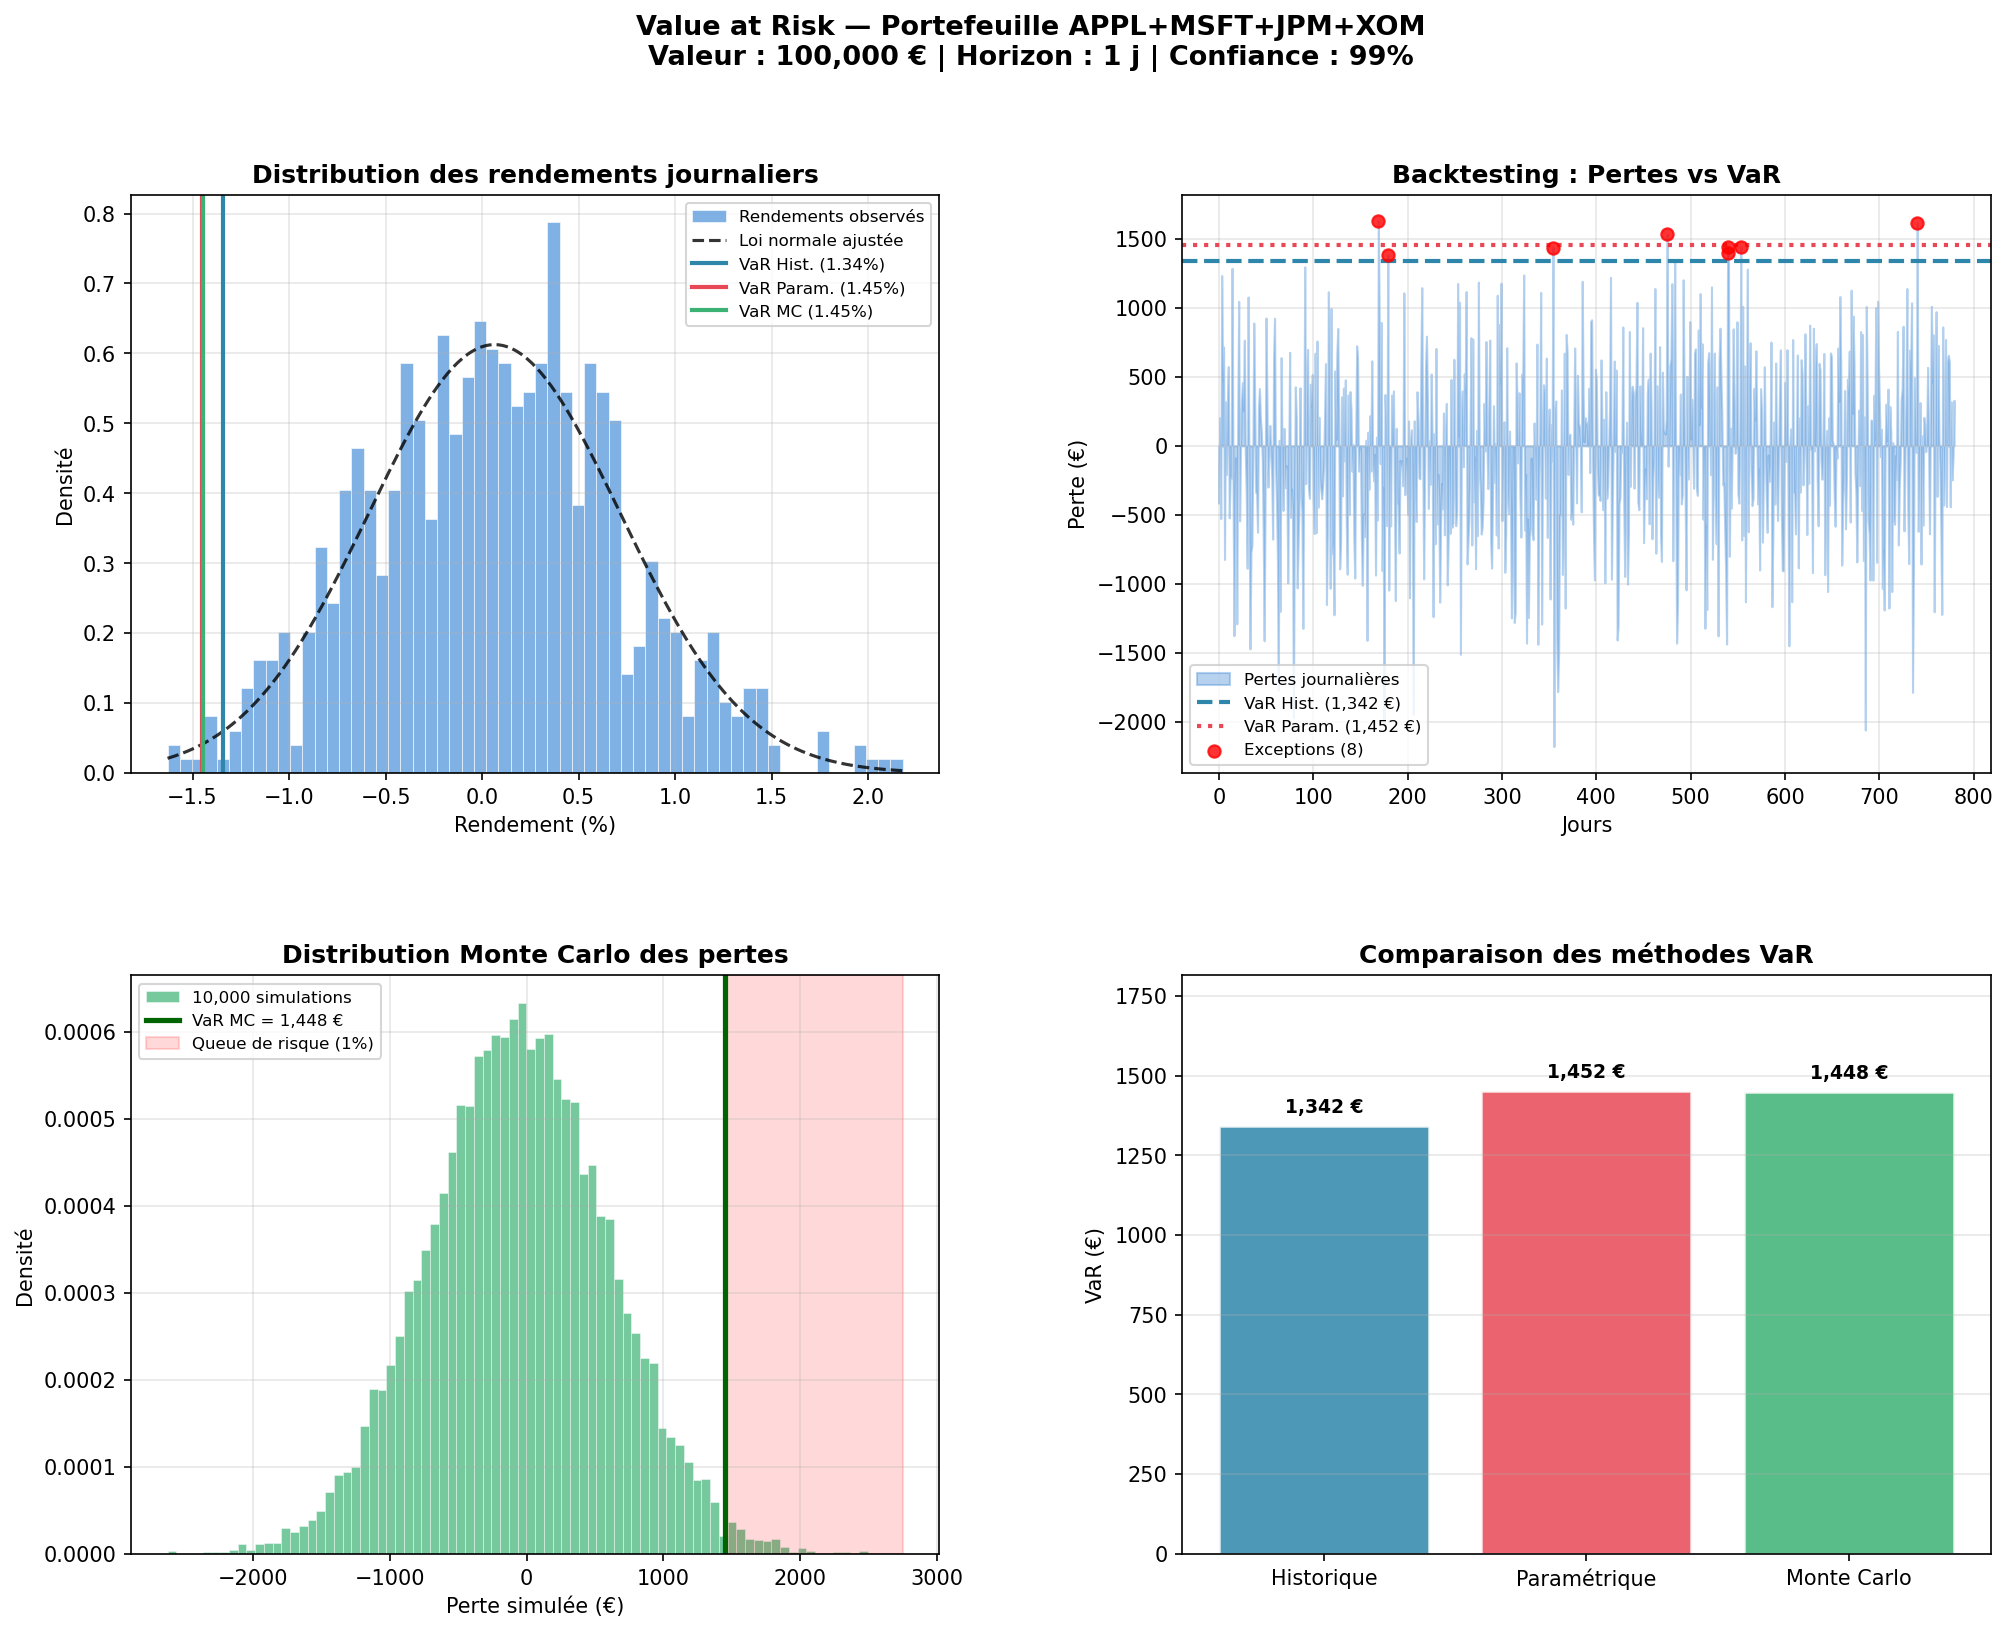

In [170]:
from IPython.display import Image, display

display(Image("var_portfolio_resultats.png"))

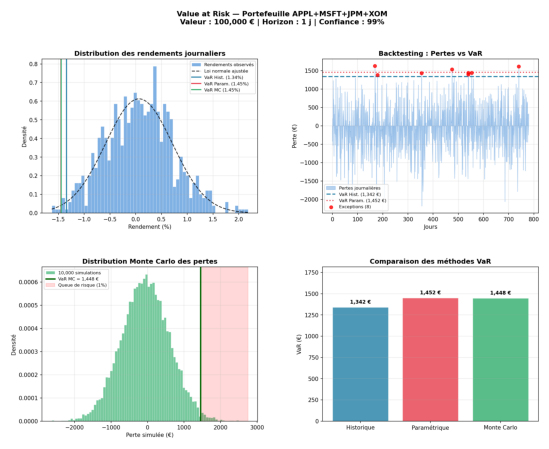

In [171]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("var_portfolio_resultats.png")

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [1]:
import os

In [2]:
print(os.getcwd())

/home/joshua


In [3]:
cd /home/joshua 

/home/joshua


In [4]:
git init

SyntaxError: invalid syntax (2830201818.py, line 1)